In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator, MultipleLocator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


In [2]:
proj_path = "/data/gc_openPMD-viewer/"

df_path = proj_path + "results/final/small_diff_prop_mem.csv"
df = pd.read_csv(df_path, header=[0])

In [3]:
def process_df(df, lower_bound, upper_bound, target_percentage=None):
    print("Before Sampling, each group size:")
    print(df.groupby(['target_percentage', 'select_set']).size() / 7)

    number_of_each_group = 10
    if target_percentage:
        # Filter DataFrame by target_percentage
        df_filtered = df[df['target_percentage'] == target_percentage]
    else:
        df_filtered = df

    # Group by select_set and get unique envelope values for each group
    unique_envelopes = df_filtered.groupby('select_set')['envelope'].unique().reset_index()

    # Rename columns for clarity
    unique_envelopes.columns = ['select_set', 'unique_envelopes']

    # print the number of unique envelopes for each group
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['unique_envelopes'][i])} unique envelopes.")

    # Function to sample envelopes
    # def sample_envelopes(envelopes, n):
    #     return list(envelopes.sample(n=min(n, len(envelopes))))

    # Apply the sampling to each group
    # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: list(pd.Series(x).sample(number_of_each_group)))
    # # unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes'].apply(lambda x: sample_envelopes(pd.Series(x), number_of_each_group))
    #
    # # Clean up the DataFrame by dropping the original unique envelopes column
    # for i in range(number_of_each_group):
    #     print(f"Group {i+1} has {len(unique_envelopes['sampled_envelopes'][i])} sampled envelopes.")

    unique_envelopes['sampled_envelopes'] = unique_envelopes['unique_envelopes']

    # Explode the sampled_envelopes into separate rows
    exploded_unique_envelopes = unique_envelopes.explode('sampled_envelopes')

    # Merge the exploded_unique_envelopes back to df_filtered to keep only relevant rows
    filtered_df = df_filtered.merge(exploded_unique_envelopes[['select_set', 'sampled_envelopes']],
                                    left_on=['select_set', 'envelope'],
                                    right_on=['select_set', 'sampled_envelopes'])

    # Drop the 'sampled_envelopes' column as it's now redundant
    filtered_df = filtered_df.drop(columns='sampled_envelopes')

    print("")
    print(filtered_df.groupby(['target_percentage', 'select_set']).size() / 7)

    filtered_df = filtered_df[['target_percentage', 'select_set', 'test_type', 'query_index_time_elapsed', 'remove_duplication_time_elapsed',
                               'sort_block_metadata_time_elapsed', 'find_optimal_read_solution_time_elapsed',
                               'get_target_data_time_elapsed', 'get_support_data_time_elapsed',
                               'data_calculation_time_elapsed', 'data_apply_select_time_elapsed', 'apply_particle_level_select_array_time_elapsed', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df['indexing'] = filtered_df['query_index_time_elapsed'] + df['remove_duplication_time_elapsed'] + df['sort_block_metadata_time_elapsed'] + df['find_optimal_read_solution_time_elapsed']
    filtered_df['IO_time'] = filtered_df['get_target_data_time_elapsed'] + df['get_support_data_time_elapsed']
    filtered_df['calculation'] = filtered_df['data_calculation_time_elapsed'] + df['data_apply_select_time_elapsed'] + df['apply_particle_level_select_array_time_elapsed']

    filtered_df = filtered_df[['target_percentage', 'select_set', 'test_type', 'indexing', 'IO_time', 'calculation', 'total_time_elapsed', 'query_result_size', 'chunk_range_size', 'total_memory_used', 'data_size']]

    filtered_df = filtered_df[filtered_df['data_size'] <= upper_bound]
    filtered_df = filtered_df[filtered_df['data_size'] >= lower_bound]

    # Group by select_set and test_type, then compute the average value
    averaged_df = filtered_df.groupby(['target_percentage', 'select_set', 'test_type']).mean().reset_index()


    # only keep the select_set with specific values: ('ux',),  ('ux','uy'),  ('ux','uy','uz'),  ('ux','uy','uz','x'), ('ux','uy','uz','x','y'), ('ux','uy','uz','x','y','z')
    # averaged_df = averaged_df[averaged_df['select_set'].isin(["('ux',)", "('ux','uy')", "('ux','uy','uz')", "('ux','uy','uz','x')", "('ux','uy','uz','x','y')", "('ux','uy','uz','x','y','z')"])]
    # print(averaged_df)
    # a new column to indicate the length of select_set
    averaged_df['select_set_length'] = averaged_df['select_set'].apply(lambda x: len(eval(x)))
    averaged_df['plot_from_0'] = averaged_df['select_set_length'].apply(lambda x: x - 1)

    # sort by select_set_length
    averaged_df = averaged_df.sort_values('select_set_length')

    averaged_df['direct_io_number'] = averaged_df['select_set_length'] * averaged_df['query_result_size']
    averaged_df['grouping_io_number'] = averaged_df['select_set_length'] * averaged_df['chunk_range_size']
    return averaged_df


In [4]:
global_tick_fontsize = 18
global_label_fontsize = 24
global_annotation_fontsize = 18
global_legend_fontsize = 18

In [5]:
averaged_df = process_df(df, 0, 3e10)
averaged_df

Before Sampling, each group size:
target_percentage  select_set   
1.00%              ('x','y','z')    14.285714
10.00%             ('x','y','z')    14.285714
30.00%             ('x','y','z')    14.285714
50.00%             ('x','y','z')    14.285714
70.00%             ('x','y','z')    14.285714
90.00%             ('x','y','z')    14.285714
dtype: float64

target_percentage  select_set   
1.00%              ('x','y','z')    14.285714
10.00%             ('x','y','z')    14.285714
30.00%             ('x','y','z')    14.285714
50.00%             ('x','y','z')    14.285714
70.00%             ('x','y','z')    14.285714
90.00%             ('x','y','z')    14.285714
dtype: float64


,target_percentage,select_set,test_type,indexing,IO_time,calculation,total_time_elapsed,query_result_size,chunk_range_size,total_memory_used,data_size,select_set_length,plot_from_0,direct_io_number,grouping_io_number
0,1.00%,"('x','y','z')",1.0,NaN,148.676318,1.145307,149.846631,NaN,NaN,5.965,413661.45,3,2,NaN,NaN
27,90.00%,"('x','y','z')",3.0,NaN,147.979311,1.476981,149.598153,11896.10,11896.10,2.100,36951268.15,3,2,35688.30,35688.30
26,90.00%,"('x','y','z')",2.0,NaN,147.830049,1.492756,149.580567,11896.10,11896.10,6.155,36951268.15,3,2,35688.30,35688.30
25,90.00%,"('x','y','z')",1.0,NaN,148.865694,1.479316,150.369808,NaN,NaN,5.605,36951268.15,3,2,NaN,NaN
24,70.00%,"('x','y','z')",25.0,NaN,2.247888,0.916534,3.289256,11177.80,1.00,2.650,28865357.10,3,2,33533.40,3.00
23,70.00%,"('x','y','z')",24.0,0.196191,2.270839,0.926281,3.427127,11177.80,1.00,2.350,28865357.10,3,2,33533.40,3.00
22,70.00%,"('x','y','z')",3.0,NaN,139.137968,1.365372,140.640706,11177.80,11177.80,5.705,28865357.20,3,2,33533.40,33533.40
21,70.00%,"('x','y','z')",2.0,NaN,139.457680,1.363388,141.068529,11177.80,11177.80,5.645,28865357.20,3,2,33533.40,33533.40
20,70.00%,"('x','y','z')",1.0,NaN,148.703440,1.423101,150.151636,NaN,NaN,5.735,28865357.20,3,2,NaN,NaN
19,50.00%,"('x','y','z')",25.0,NaN,2.261018,0.719035,3.145512,9821.20,2.60,2.000,20644000.80,3,2,29463.60,7.80


[-30000000.         0.  30000000.  60000000.  90000000.]
[-3.  0.  3.  6.  9.]


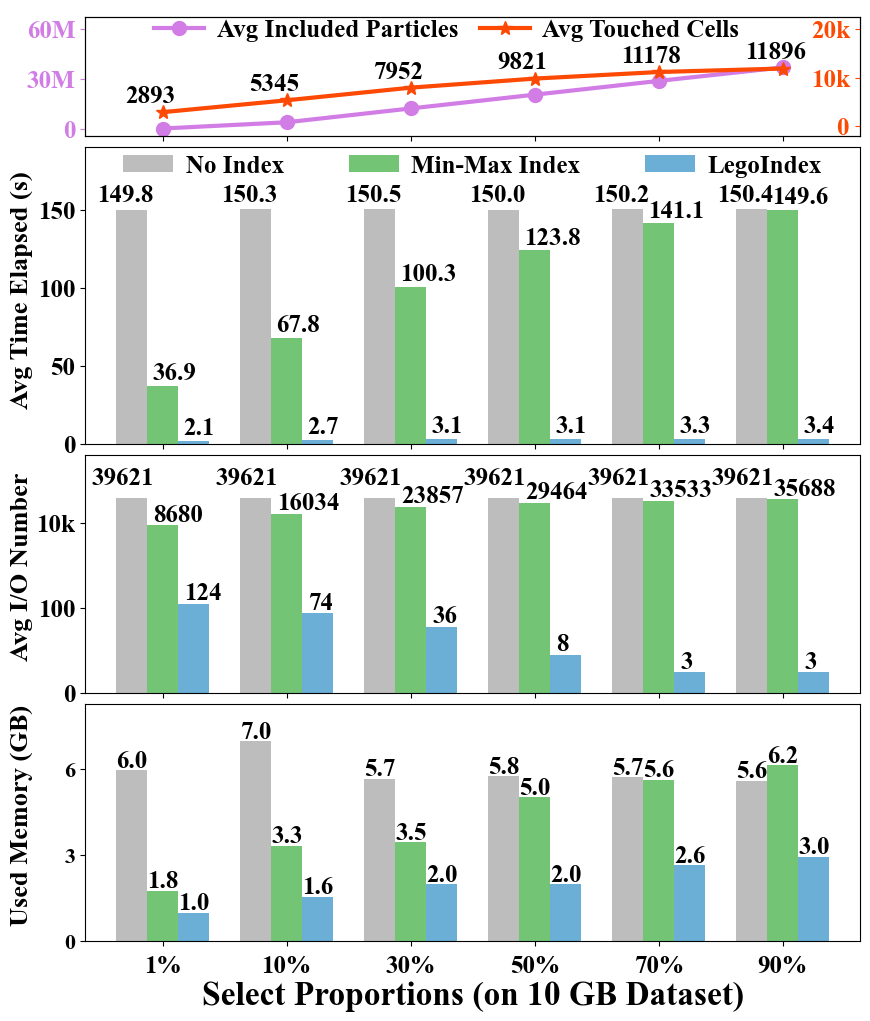

In [6]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]
plot_df = plot_df[plot_df['select_set_length'] <= 3]
#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 12), gridspec_kw={'height_ratios': row_ratios})

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(-4e6, 6.7e7)

ax.yaxis.set_major_locator(MultipleLocator(3e7))
current_values = ax.get_yticks()
print(current_values)

ax.set_yticklabels([f"{round(y / 1000000)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.06, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-35)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.3, y + 2000),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-2000, 22500)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(10000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "    0", "10k", "20k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.48, 1.17), columnspacing=2.6, handletextpad=0.5)
for text in legend.get_texts():
    text.set_fontweight('bold')


''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='target_percentage', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0.02, 1.05), columnspacing=2.6, handletextpad=0.5)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)

for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i < 6:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 5), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.04, p.get_height() + 4), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 190)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
ax.set_yticklabels([str(int(y*2)) if y != 0 else "0" for y in current_values])
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)


''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='target_percentage', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

for i, p in enumerate(ax.patches):
    if i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() + 0.05, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.6)
# x label
ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)

current_values = ax.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
y_ticks = ["0", "100", "10k"]
# ax.set_yticklabels([str(int(pow(10, y*2))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='target_percentage', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 8.3)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(3))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "3", "6"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize - 2)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
ax.set_xlabel("Select Proportions (on 10 GB Dataset)", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
""""""
plt.gca().set_xticklabels([x.get_text()[:-4] + '%' for x in ax.get_xticklabels()])
plt.savefig(proj_path + "plot/final/small_diff_proportion_v2.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[-20000000.         0.  20000000.  40000000.  60000000.]
1111 [0. 1. 2. 3. 4. 5. 6.]
[-3.  0.  3.  6.  9.]


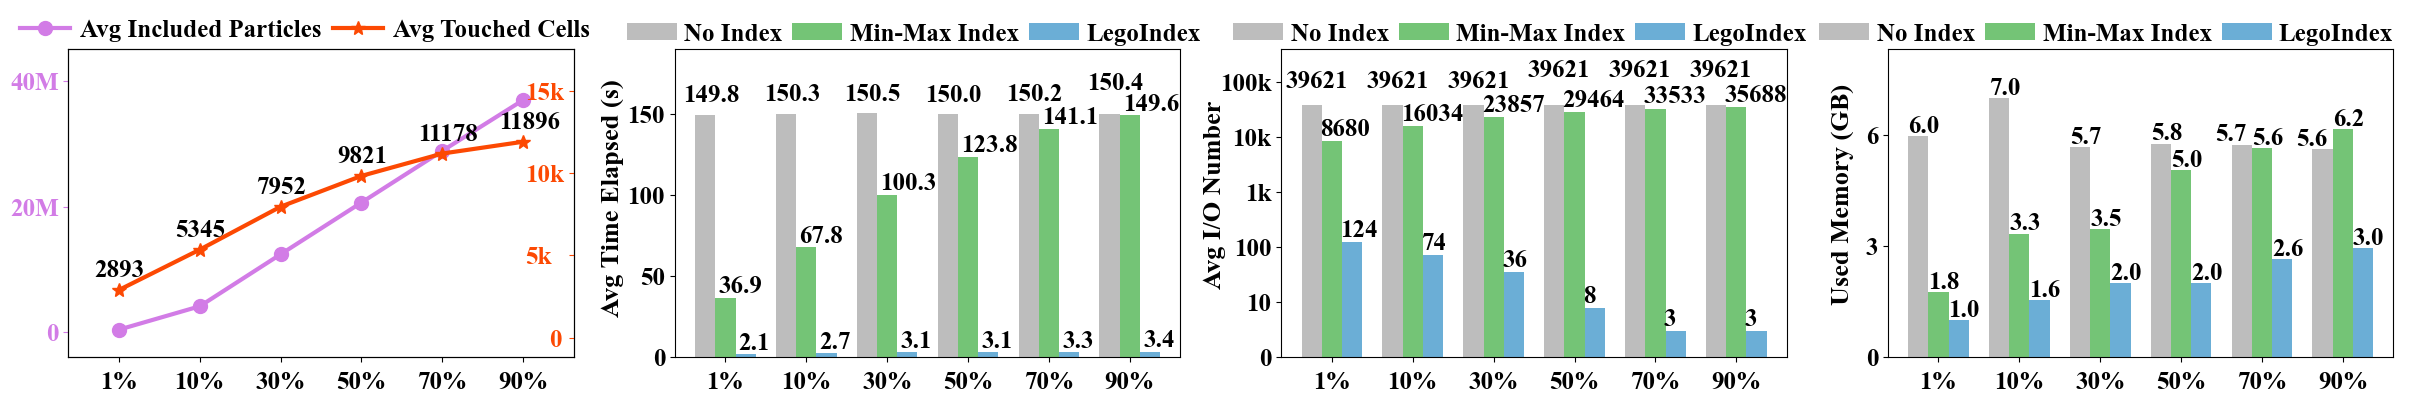

In [7]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]
plot_df = plot_df[plot_df['select_set_length'] <= 3]
#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, figsize=(30, 4))

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(-4e6, 4.5e7)

ax.yaxis.set_major_locator(MultipleLocator(2e7))
current_values = ax.get_yticks()
print(current_values)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([f"{round(y / 1000000)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(-0.14, 1.17), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-35)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.3, y + 800),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 17500)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(5000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "    0", "5k", "10k", "15k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.48, 1.17), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")
ax2.set_xlabel("")

''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='target_percentage', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.14, 1.16), columnspacing=0.4, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)
ax.tick_params(axis='x', rotation=0)
for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 8), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.04, p.get_height() + 3), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 190)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.1, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
ax.set_yticklabels([str(int(y*2)) if y != 0 else "0" for y in current_values])
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)
ax.set_xlabel("")

''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='target_percentage', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.14, 1.16), columnspacing=0.4, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax.tick_params(axis='x', rotation=0)
for i, p in enumerate(ax.patches):
    if i < 3:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i < 6:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.5), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(10**p.get_height())), (p.get_x() -0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 5.6)
# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.11, 0.53)

current_values = ax.get_yticks()
print(1111, current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))

# ax.set_yticklabels([str(int(pow(10, y))) if y != 0 else "0" for y in current_values])
y_ticks = ["0", "10", "100", "1k", "10k", "100k"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")
# ax.get_legend().remove()

''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='target_percentage', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.18, 1.16), columnspacing=0.4, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    if i == 4 or i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')

    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 8.3)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(3))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
y_ticks = ["-500", "0", "3", "6"]
ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# ax.get_legend().remove()
# ax.set_xlabel("Select Proportions (on 10 GB Dataset)", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels([x.get_text()[:-4] + '%' for x in ax.get_xticklabels()])
""""""

plt.savefig(proj_path + "plot/final/small_diff_proportion_v3.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[-20000000.         0.  20000000.  40000000.  60000000.]
1111 [-10000.      0.  10000.  20000.  30000.  40000.  50000.]
[-2.  0.  2.  4.  6.  8. 10.]


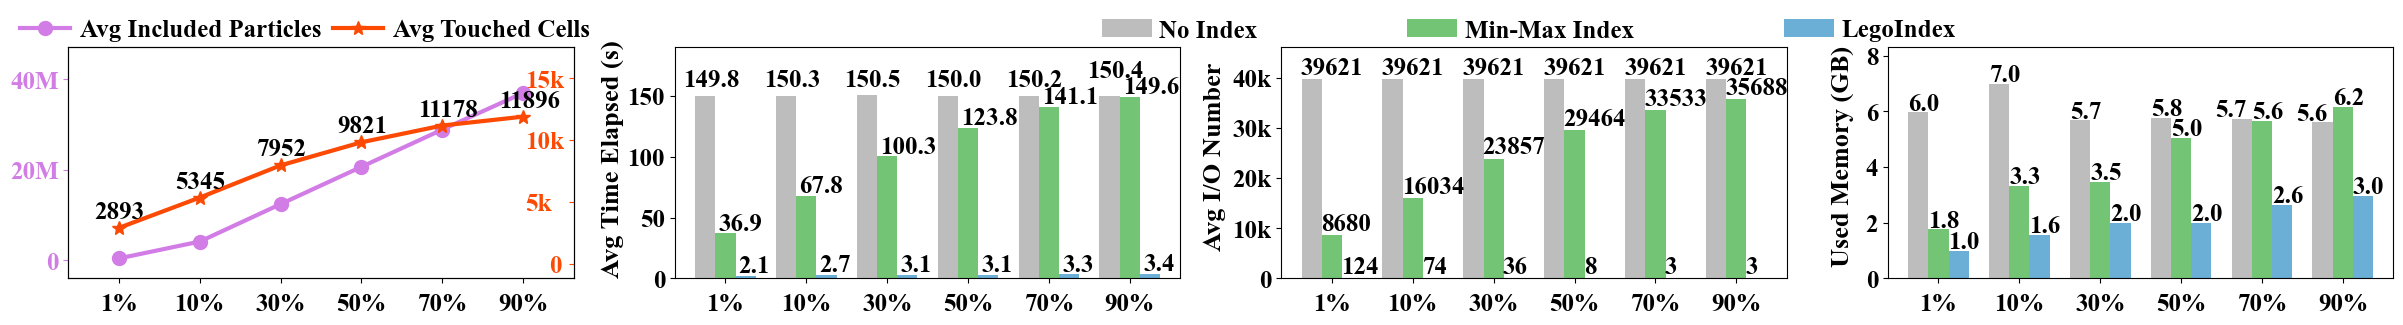

In [8]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]
plot_df = plot_df[plot_df['select_set_length'] <= 3]
#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, figsize=(30, 3))

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(-4e6, 4.7e7)

ax.yaxis.set_major_locator(MultipleLocator(2e7))
current_values = ax.get_yticks()
print(current_values)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([f"{round(y / 1000000)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-35)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.3, y + 800),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 17500)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(5000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "    0", "5k", "10k", "15k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.48, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")
ax2.set_xlabel("")

''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='target_percentage', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=0.4, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)
ax.tick_params(axis='x', rotation=0)
for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 8), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.04, p.get_height() + 3), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 190)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.1, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
ax.set_yticklabels([str(int(y*2)) if y != 0 else "0" for y in current_values])
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)
ax.set_xlabel("")
ax.get_legend().remove()

''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
# plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='target_percentage', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.4, 1.22), columnspacing=6, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax.tick_params(axis='x', rotation=0)
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height())), (p.get_x()-0.01, p.get_height() + 1000), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i < 3:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.5), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() -0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 46000)
# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.11, 0.53)

ax.yaxis.set_major_locator(MultipleLocator(10000))
current_values = ax.get_yticks()
print(1111, current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))


# ax.set_yticklabels([str(int(pow(10, y))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels([f"{round(y / 1000)}k" if y != 0 else "0" for y in current_values])
# y_ticks = ["0", "10", "100", "1k", "10k", "100k"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")


''' subplot 4 '''
ax = axes[3]
plot_df.pivot(index='target_percentage', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.182, 1.16), columnspacing=0.4, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    if i == 4 or i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')

    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 8.3)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(2))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
# y_ticks = ["-500", "0", "3", "6"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
# ax.set_xlabel("Select Proportions (on 10 GB Dataset)", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels([x.get_text()[:-4] + '%' for x in ax.get_xticklabels()])
""""""

plt.savefig(proj_path + "plot/final/small_diff_proportion_v4.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[-20000000.         0.  20000000.  40000000.  60000000.]
1111 [-10000.      0.  10000.  20000.  30000.  40000.  50000.]
[-2.  0.  2.  4.  6.  8. 10.]


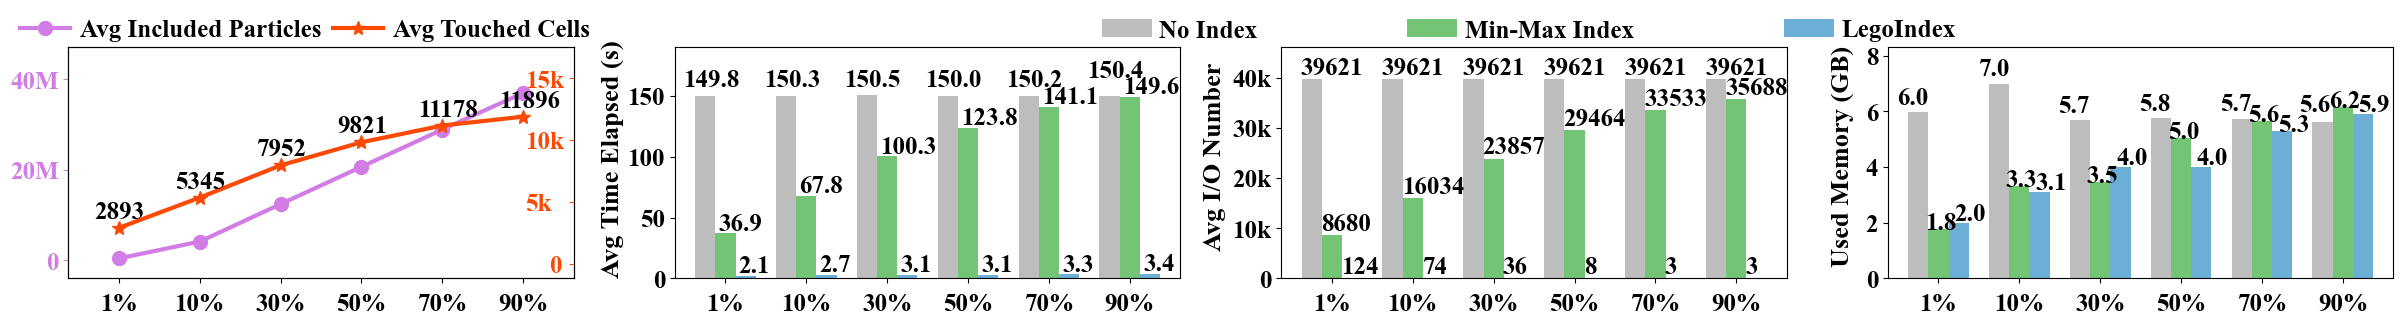

In [9]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]
plot_df = plot_df[plot_df['select_set_length'] <= 3]
#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, figsize=(30, 3))

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#d27ce6', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(-4e6, 4.7e7)

ax.yaxis.set_major_locator(MultipleLocator(2e7))
current_values = ax.get_yticks()
print(current_values)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([f"{round(y / 1000000)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-35)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fc4903', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.3, y + 800),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 17500)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(5000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "    0", "5k", "10k", "15k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.48, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")
ax2.set_xlabel("")

''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='target_percentage', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=0.4, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)
ax.tick_params(axis='x', rotation=0)
for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 8), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.04, p.get_height() + 3), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 190)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.1, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
ax.set_yticklabels([str(int(y*2)) if y != 0 else "0" for y in current_values])
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)
ax.set_xlabel("")
ax.get_legend().remove()

''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
# plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='target_percentage', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.4, 1.22), columnspacing=6, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax.tick_params(axis='x', rotation=0)
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height())), (p.get_x()-0.01, p.get_height() + 1000), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i < 3:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.5), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() -0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 46000)
# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.11, 0.53)

ax.yaxis.set_major_locator(MultipleLocator(10000))
current_values = ax.get_yticks()
print(1111, current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))


# ax.set_yticklabels([str(int(pow(10, y))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels([f"{round(y / 1000)}k" if y != 0 else "0" for y in current_values])
# y_ticks = ["0", "10", "100", "1k", "10k", "100k"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")


''' subplot 4 '''
ax = axes[3]
# plot_df.loc[plot_df['test_type'] == 25] = plot_df.loc[plot_df['test_type'] == 25].apply(lambda x: 2 * x)
for index, row in plot_df.iterrows():
    if row['test_type'] == 25:
        plot_df.loc[index, ['total_memory_used']] *= 2

plot_df.pivot(index='target_percentage', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#bdbdbd', '#74c476', '#6baed6'])
ax.tick_params(axis='x', rotation=0)

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.182, 1.16), columnspacing=0.4, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.14, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.16, p.get_height() + 0.4), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 16:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.08, p.get_height()), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.04, p.get_height()), fontsize=global_annotation_fontsize , fontweight='bold')

    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 8.3)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(2))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
# y_ticks = ["-500", "0", "3", "6"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
# ax.set_xlabel("Select Proportions (on 10 GB Dataset)", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels([x.get_text()[:-4] + '%' for x in ax.get_xticklabels()])
""""""

plt.savefig(proj_path + "plot/final/small_diff_proportion_v5.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

[-20000000.         0.  20000000.  40000000.  60000000.]
1111 [-10000.      0.  10000.  20000.  30000.  40000.  50000.]
[-2.  0.  2.  4.  6.  8. 10.]


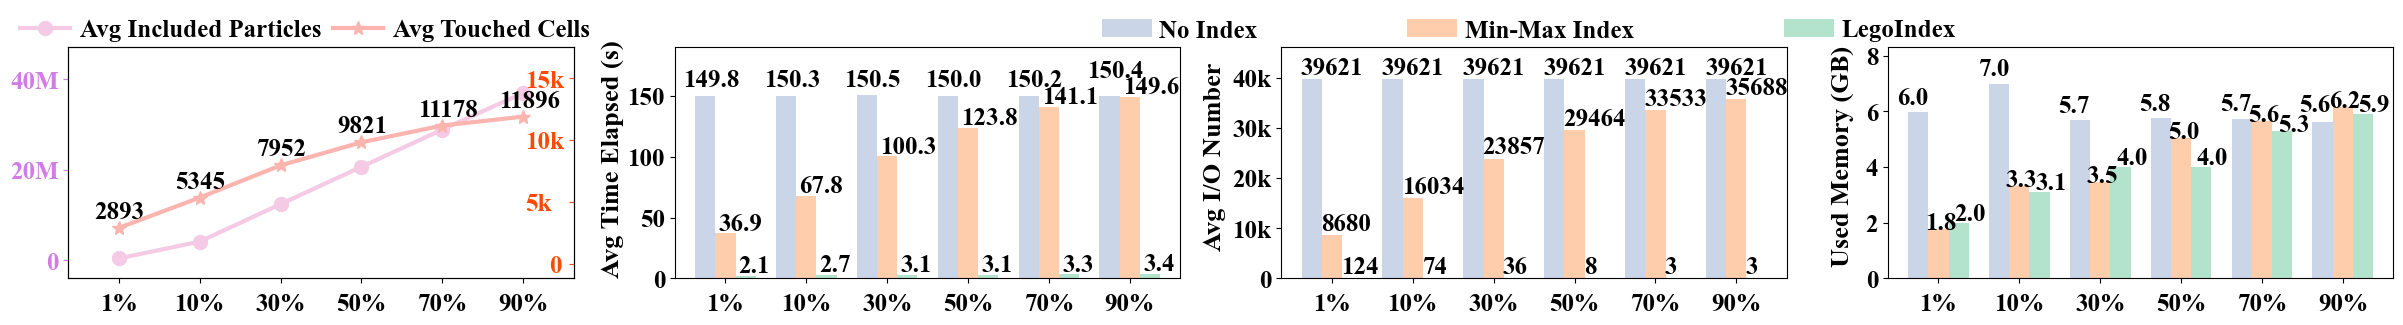

In [10]:
# only keep the test_type with specific values: 1 and 25\
plot_df = averaged_df[averaged_df['test_type'].isin([1, 2, 25])]
plot_df = plot_df[plot_df['select_set_length'] <= 3]
#

row_ratios = [2, 5, 4, 4]

# fig, ax = plt.subplots()
# set figure size
fig, axes = plt.subplots(nrows=1, ncols=4, sharex=True, figsize=(30, 3))

''' subplot 1 '''
ax = axes[0]
plot_df[averaged_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='data_size').plot(kind='line', ax=ax, color='#f4cae4', marker='o', markersize=10, linewidth=3)
plt.xticks(rotation=0)
ax.set_ylim(-4e6, 4.7e7)

ax.yaxis.set_major_locator(MultipleLocator(2e7))
current_values = ax.get_yticks()
print(current_values)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([f"{round(y / 1000000)}M" if y != 0 else "0" for y in current_values])
# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#d27ce6')  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Remove the legend
# ax.get_legend().remove()
legend = ax.legend(title='', loc='upper left', labels=['Avg Included Particles'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax2 = ax.twinx()
# ax2.set_xlim((ax.get_xlim()))

# ax2.yaxis.set_tick_params(direction='in')  # Move ticks inside
ax2.yaxis.set_tick_params(direction='in', pad=-35)  # Move ticks inside
# ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


plot_df[plot_df['test_type'] == 25].pivot(index='target_percentage', columns='test_type', values='query_result_size').plot(kind='line', ax=ax2, color='#fbb4ae', marker='*', markersize=10, linewidth=3)

# Annotate each data point
for i, (x, y) in enumerate(zip(ax2.lines[0].get_xdata(), ax2.lines[0].get_ydata())):
    ax2.annotate(
        str(round(y)),  # Text label
        (x - 0.3, y + 800),  # Position (adjust y + 200 for visibility)
        fontsize=global_annotation_fontsize,
        fontweight='bold'
    )


# ax.set_autoscale_on(False)
ax2.set_ylim(-1200, 17500)

# y label
# ax.set_ylabel("Avg Touched Cells", fontsize=global_label_fontsize - 5, labelpad=25, fontweight='bold')
ax2.yaxis.set_label_coords(-0.068, 0.5)

ax2.yaxis.set_major_locator(MultipleLocator(5000))
current_values = ax2.get_yticks()
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# ax2.set_yticklabels([f"{int(y / 1000)}k" if y != 0 else "0" for y in current_values])
y_ticks = ["-1", "    0", "5k", "10k", "15k"]
ax2.set_yticklabels(y_ticks)
ax2.tick_params(axis='y', labelsize=global_tick_fontsize, colors='#fc4903')  # Adjust label size as needed


for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

legend = ax2.legend(title='', loc='upper left', labels=['Avg Touched Cells'], fontsize=global_legend_fontsize, ncol=1, frameon=False, bbox_to_anchor=(0.48, 1.22), columnspacing=2.6, handletextpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")
ax2.set_xlabel("")

''' subplot 2 '''
# the value difference between test_type 1 and 25 is too large, so we use log scale
# plot_df['total_time_elapsed'] = plot_df['total_time_elapsed'].apply(lambda x: np.log10(x+1))

# log for query_result_size and chunk_range_size
# plot_df['query_result_size'] = plot_df['query_result_size'].apply(lambda x: np.log10(x))
# plot_df['chunk_range_size'] = plot_df['chunk_range_size'].apply(lambda x: np.log10(x))

ax = axes[1]
# plot grouped bar chart, x is select_set_length, y is time_elapsed, grouped by test_type
plot_df.pivot(index='target_percentage', columns='test_type', values='total_time_elapsed').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
plt.xticks(rotation=0)
legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.14, 1.22), columnspacing=0.4, handletextpad=0.3)
# legend = ax.legend(title='', loc='upper left', labels=['OpenPMD-viewer', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(0, 1.13), columnspacing=0.8)
ax.tick_params(axis='x', rotation=0)
for text in legend.get_texts():
    text.set_fontweight('bold')

# mark the number on the top of each bar before log
for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 8), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.15, p.get_height() + 15), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.04, p.get_height() + 3), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 190)

# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg Time Elapsed (s)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.1, 0.52)

current_values = ax.get_yticks()

# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(MultipleLocator(1))
# y_ticks = ["-1", "0", "10", "100", "1k", "10k"]
ax.set_yticklabels([str(int(y*2)) if y != 0 else "0" for y in current_values])
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
plt.subplots_adjust(hspace=0.05)
ax.set_xlabel("")
ax.get_legend().remove()

''' subplot 3 '''
ax = axes[2]
plot_df.loc[plot_df['test_type'] == 1, "grouping_io_number"] = 13207 * plot_df.loc[plot_df['test_type'] == 1, "select_set_length"]
# plot_df['grouping_io_number'] = plot_df['grouping_io_number'].apply(lambda x: np.log10(x))
plot_df.pivot(index='target_percentage', columns='test_type', values='grouping_io_number').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.4, 1.22), columnspacing=6, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

ax.tick_params(axis='x', rotation=0)
for i, p in enumerate(ax.patches):
    ax.annotate(str(round(p.get_height())), (p.get_x()-0.01, p.get_height() + 1000), fontsize=global_annotation_fontsize , fontweight='bold')
    # if i < 3:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() - 0.2, p.get_height() + 0.5), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height())), (p.get_x() -0.02, p.get_height() + 0.10), fontsize=global_annotation_fontsize , fontweight='bold')

# plt.xticks(rotation=0)
# plt y range
ax.set_ylim(0, 46000)
# x label
# ax.set_xlabel("Number of Particle Attributes Involved", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
# y label
ax.set_ylabel("Avg I/O Number", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.11, 0.53)

ax.yaxis.set_major_locator(MultipleLocator(10000))
current_values = ax.get_yticks()
print(1111, current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))


# ax.set_yticklabels([str(int(pow(10, y))) if y != 0 else "0" for y in current_values])
ax.set_yticklabels([f"{round(y / 1000)}k" if y != 0 else "0" for y in current_values])
# y_ticks = ["0", "10", "100", "1k", "10k", "100k"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)

# plt.xticks(fontweight='bold')
# plt.yticks(fontweight='bold')

ax.tick_params(axis='y', labelsize=global_tick_fontsize)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.set_xlabel("")


''' subplot 4 '''
ax = axes[3]
# plot_df.loc[plot_df['test_type'] == 25] = plot_df.loc[plot_df['test_type'] == 25].apply(lambda x: 2 * x)
for index, row in plot_df.iterrows():
    if row['test_type'] == 25:
        plot_df.loc[index, ['total_memory_used']] *= 2

plot_df.pivot(index='target_percentage', columns='test_type', values='total_memory_used').plot(kind='bar', ax=ax, width=0.75, color=['#cbd5e8', '#fdcdac', '#b3e2cd'])
ax.tick_params(axis='x', rotation=0)

legend = ax.legend(title='', loc='upper left', labels=['No Index', 'Min-Max Index', 'LegoIndex'], fontsize=global_legend_fontsize, ncol=3, frameon=False, bbox_to_anchor=(-0.182, 1.16), columnspacing=0.4, handletextpad=0.3)
for text in legend.get_texts():
    text.set_fontweight('bold')

for i, p in enumerate(ax.patches):
    if i < 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.14, p.get_height() + 0.3), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 5:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.16, p.get_height() + 0.4), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i == 16:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.08, p.get_height()), fontsize=global_annotation_fontsize , fontweight='bold')
    elif i > 11:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 0.1), fontsize=global_annotation_fontsize , fontweight='bold')
    else:
        ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.04, p.get_height()), fontsize=global_annotation_fontsize , fontweight='bold')

    # if i == 0:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 60), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 6:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() - 0.2, p.get_height() + 40), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i < 9:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 110), fontsize=global_annotation_fontsize , fontweight='bold')
    # elif i > 11:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x() + 0.07, p.get_height() + 30), fontsize=global_annotation_fontsize , fontweight='bold')
    # else:
    #     ax.annotate(str(round(p.get_height(), 1)), (p.get_x(), p.get_height() + 50), fontsize=global_annotation_fontsize , fontweight='bold')

ax.set_ylim(0, 8.3)
# x label
ax.yaxis.set_label_coords(-0.068, 0.53)
ax.yaxis.set_major_locator(MultipleLocator(2))

current_values = ax.get_yticks()
print(current_values)
# plt.gca().yaxis.set_major_formatter(FuncFormatter(exp_formatter))
# plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=3))
# ax.set_yticklabels([str(int(y)) if y != 0 else "0" for y in current_values])
# y_ticks = ["-500", "0", "3", "6"]
# ax.set_yticklabels(y_ticks)

# Adjust tick label fontsize
ax.tick_params(axis='y', labelsize=global_tick_fontsize)  # Adjust label size as needed
ax.tick_params(axis='x', labelsize=global_tick_fontsize, pad=7)


ax.set_ylabel("Used Memory (GB)", fontsize=global_label_fontsize - 5, fontweight='bold')
ax.yaxis.set_label_coords(-0.068, 0.53)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.get_legend().remove()
# ax.set_xlabel("Select Proportions (on 10 GB Dataset)", fontsize=global_label_fontsize, labelpad=2, fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels([x.get_text()[:-4] + '%' for x in ax.get_xticklabels()])
""""""

plt.savefig(proj_path + "plot/final/small_diff_proportion_v6.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()
print()

In [11]:
plot_df

,target_percentage,select_set,test_type,indexing,IO_time,calculation,total_time_elapsed,query_result_size,chunk_range_size,total_memory_used,data_size,select_set_length,plot_from_0,direct_io_number,grouping_io_number
0,1.00%,"('x','y','z')",1.0,NaN,148.676318,1.145307,149.846631,NaN,NaN,5.965,413661.45,3,2,NaN,39621.00
26,90.00%,"('x','y','z')",2.0,NaN,147.830049,1.492756,149.580567,11896.10,11896.10,6.155,36951268.15,3,2,35688.30,35688.30
25,90.00%,"('x','y','z')",1.0,NaN,148.865694,1.479316,150.369808,NaN,NaN,5.605,36951268.15,3,2,NaN,39621.00
24,70.00%,"('x','y','z')",25.0,NaN,2.247888,0.916534,3.289256,11177.80,1.00,5.300,28865357.10,3,2,33533.40,3.00
21,70.00%,"('x','y','z')",2.0,NaN,139.457680,1.363388,141.068529,11177.80,11177.80,5.645,28865357.20,3,2,33533.40,33533.40
20,70.00%,"('x','y','z')",1.0,NaN,148.703440,1.423101,150.151636,NaN,NaN,5.735,28865357.20,3,2,NaN,39621.00
19,50.00%,"('x','y','z')",25.0,NaN,2.261018,0.719035,3.145512,9821.20,2.60,4.000,20644000.80,3,2,29463.60,7.80
16,50.00%,"('x','y','z')",2.0,NaN,122.514408,1.100280,123.845822,9821.20,9821.20,5.040,20644002.40,3,2,29463.60,29463.60
15,50.00%,"('x','y','z')",1.0,NaN,148.655524,1.323056,150.002956,NaN,NaN,5.760,20644002.40,3,2,NaN,39621.00
14,30.00%,"('x','y','z')",25.0,NaN,2.351769,0.541941,3.116709,7952.25,11.95,4.000,12408652.45,3,2,23856.75,35.85
